# HerWay — Crime Severity Scoring

**Purpose:** Build a per-community Crime Severity Score from the filtered Chicago crime dataset.  
**Output:** `data/crime_severity_by_community.csv` — merge-ready with Reddit and 311 data.

**Score components:**
- Violent crime ratio (40%) — homicide, sexual assault, robbery, battery, assault, kidnapping, stalking
- Domestic crime rate (25%) — % of crimes flagged domestic (women's safety focus)
- Crime volume normalized (20%) — relative volume across communities
- Inverse arrest rate (15%) — low arrest rate = less accountability

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import requests
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

## 2. Load Crime Data

In [2]:
df = pd.read_csv('../data/crimes_filtered_by_zip.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p')
df['hour'] = df['Date'].dt.hour
df['month'] = df['Date'].dt.month

# Drop rows without a community area assignment
df = df.dropna(subset=['Community Area'])
df['Community Area'] = df['Community Area'].astype(int)

print(f'Rows: {len(df):,}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Community areas present: {df["Community Area"].nunique()}')

Rows: 72,153
Date range: 2025-01-01 to 2026-01-30
Community areas present: 37


## 3. Community Area Code → Name Mapping

In [3]:
resp = requests.get(
    'https://data.cityofchicago.org/resource/igwz-8jzy.json?$limit=100',
    verify=False
)
resp.raise_for_status()

CA_MAP = {
    int(r['area_numbe']): r['community'].title()
    for r in resp.json()
}

df['community_name'] = df['Community Area'].map(CA_MAP)
print(f'Communities mapped: {df["community_name"].notna().sum():,} / {len(df):,} rows')

Communities mapped: 72,153 / 72,153 rows


## 4. Define Crime Severity Categories

In [4]:
VIOLENT = [
    'HOMICIDE', 'CRIMINAL SEXUAL ASSAULT', 'ROBBERY',
    'BATTERY', 'ASSAULT', 'KIDNAPPING', 'STALKING',
    'WEAPONS VIOLATION', 'SEX OFFENSE'
]

df['is_violent']   = df['Primary Type'].isin(VIOLENT)
df['is_domestic']  = df['Domestic'].astype(bool)
df['is_arrested']  = df['Arrest'].astype(bool)

## 5. Compute Per-Community Metrics

In [5]:
def peak_hour(series):
    return series.value_counts().idxmax()

def top_crimes(group, n=3):
    return group['Primary Type'].value_counts().head(n).index.tolist()

# Core metrics
metrics = df.groupby(['Community Area', 'community_name']).agg(
    total_crimes    = ('Primary Type', 'count'),
    violent_crimes  = ('is_violent',   'sum'),
    domestic_crimes = ('is_domestic',  'sum'),
    arrests         = ('is_arrested',  'sum'),
    peak_hour       = ('hour',         peak_hour),
).reset_index()

# Ratios
metrics['violent_ratio']  = metrics['violent_crimes']  / metrics['total_crimes']
metrics['domestic_rate']  = metrics['domestic_crimes'] / metrics['total_crimes']
metrics['arrest_rate']    = metrics['arrests']         / metrics['total_crimes']

# Top 3 crime types per community
top3 = (
    df.groupby('community_name')['Primary Type']
    .apply(lambda x: x.value_counts().head(3).index.tolist())
    .reset_index()
)
top3.columns = ['community_name', 'top_crime_types']
top3['top_crime_1'] = top3['top_crime_types'].apply(lambda x: x[0] if len(x) > 0 else None)
top3['top_crime_2'] = top3['top_crime_types'].apply(lambda x: x[1] if len(x) > 1 else None)
top3['top_crime_3'] = top3['top_crime_types'].apply(lambda x: x[2] if len(x) > 2 else None)

metrics = metrics.merge(top3[['community_name','top_crime_1','top_crime_2','top_crime_3']], on='community_name')

print(metrics[['community_name','total_crimes','violent_ratio','domestic_rate','arrest_rate']]
      .sort_values('total_crimes', ascending=False).to_string(index=False))

        community_name  total_crimes  violent_ratio  domestic_rate  arrest_rate
        Auburn Gresham          6449          0.383          0.300        0.131
             Lake View          6200          0.230          0.050        0.094
                  Loop          5792          0.257          0.039        0.229
               Chatham          5697          0.375          0.258        0.149
Greater Grand Crossing          5190          0.437          0.291        0.167
             West Town          4565          0.243          0.099        0.108
          Logan Square          4426          0.239          0.115        0.172
         Humboldt Park          4144          0.366          0.208        0.265
         South Chicago          3823          0.391          0.278        0.144
              Woodlawn          3802          0.383          0.245        0.146
                Austin          2915          0.407          0.277        0.199
    Washington Heights          2473    

## 6. Compute Crime Severity Score (0–100)

| Component | Weight | Rationale |
|---|---|---|
| Violent crime ratio | 40% | Direct personal safety risk |
| Domestic crime rate | 25% | Women's safety focus |
| Volume (normalized) | 20% | Absolute burden on residents |
| Inverse arrest rate | 15% | Low accountability adds risk |

In [6]:
def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

metrics['volume_norm']        = minmax(metrics['total_crimes'])
metrics['violent_ratio_norm'] = minmax(metrics['violent_ratio'])
metrics['domestic_norm']      = minmax(metrics['domestic_rate'])
metrics['no_arrest_norm']     = minmax(1 - metrics['arrest_rate'])

metrics['crime_severity_score'] = (
    0.40 * metrics['violent_ratio_norm'] +
    0.25 * metrics['domestic_norm']      +
    0.20 * metrics['volume_norm']        +
    0.15 * metrics['no_arrest_norm']
) * 100

metrics['crime_severity_score'] = metrics['crime_severity_score'].round(1)

# Tier classification based on score tertiles
t33 = metrics['crime_severity_score'].quantile(0.33)
t66 = metrics['crime_severity_score'].quantile(0.66)

metrics['crime_tier'] = pd.cut(
    metrics['crime_severity_score'],
    bins=[-np.inf, t33, t66, np.inf],
    labels=['Lower Activity', 'Moderate Activity', 'Higher Activity']
)

print(f'Tier thresholds: Lower < {t33:.1f} | Moderate {t33:.1f}–{t66:.1f} | Higher > {t66:.1f}\n')
print(metrics[['community_name','total_crimes','crime_severity_score','crime_tier']]
      .sort_values('crime_severity_score', ascending=False).to_string(index=False))

Tier thresholds: Lower < 49.9 | Moderate 49.9–59.9 | Higher > 59.9

        community_name  total_crimes  crime_severity_score        crime_tier
        Auburn Gresham          6449                80.500   Higher Activity
Greater Grand Crossing          5190                78.400   Higher Activity
               Chatham          5697                73.700   Higher Activity
       Washington Park          1742                71.000   Higher Activity
         South Chicago          3823                70.700   Higher Activity
              Woodlawn          3802                67.500   Higher Activity
                Austin          2915                66.800   Higher Activity
              Avondale            48                64.700   Higher Activity
          West Pullman           879                63.700   Higher Activity
         South Deering          1755                61.000   Higher Activity
           Morgan Park          1711                60.900   Higher Activity
        

## 7. Score Distribution

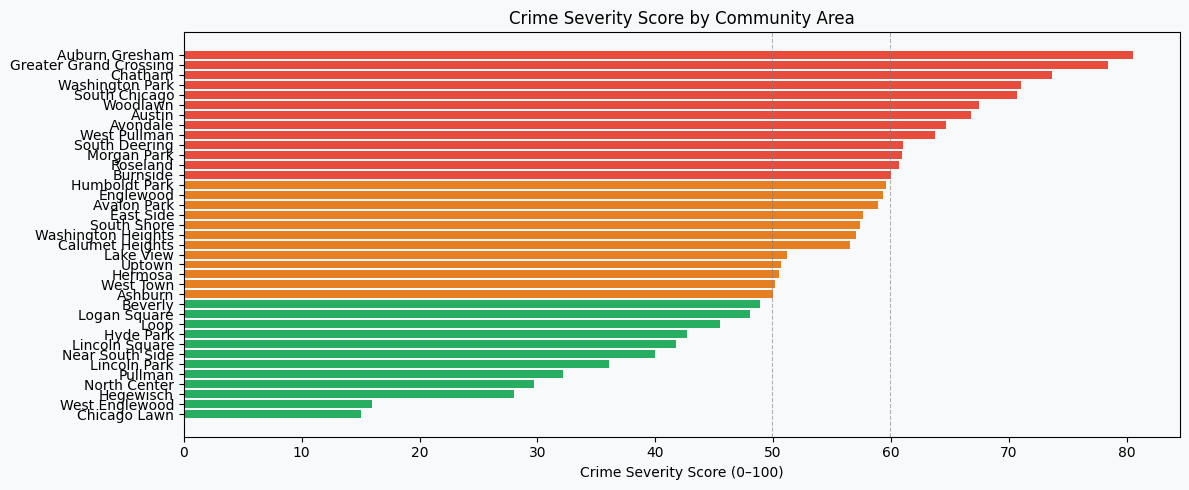

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = metrics['crime_tier'].map({
    'Higher Activity': '#e74c3c',
    'Moderate Activity': '#e67e22',
    'Lower Activity': '#27ae60'
})

plot_data = metrics.sort_values('crime_severity_score', ascending=True)
bars = ax.barh(plot_data['community_name'], plot_data['crime_severity_score'],
               color=plot_data['crime_tier'].map({
                   'Higher Activity': '#e74c3c',
                   'Moderate Activity': '#e67e22',
                   'Lower Activity': '#27ae60'
               }))

ax.axvline(t33, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(t66, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Crime Severity Score (0–100)')
ax.set_title('Crime Severity Score by Community Area')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()

## 8. Select 10–12 Communities for the App

**Strategy:** Anchor on the 10 neighborhoods already present in the 311 dataset (already filtered/assigned).  
Check where they fall in the crime spectrum — supplement with 1–2 if coverage gaps exist.

In [8]:
# 311 neighborhood names → official community area names
NAME_ALIGN = {
    'Chatham':       'Chatham',
    'Humboldt Park': 'Humboldt Park',
    'Lakeview':      'Lake View',
    'Logan Square':  'Logan Square',
    'Loop':          'Loop',
    'Morgan Park':   'Morgan Park',
    'South Chicago': 'South Chicago',
    'Uptown':        'Uptown',
    'Wicker Park':   'West Town',   # Wicker Park is a sub-neighborhood of West Town CA
    'Woodlawn':      'Woodlawn',
}

ca_names_311 = list(NAME_ALIGN.values())
selected_311 = metrics[metrics['community_name'].isin(ca_names_311)].copy()
selected_311['source_311_name'] = selected_311['community_name'].map(
    {v: k for k, v in NAME_ALIGN.items()}
)

print('311 communities mapped to crime data scores:')
print(selected_311[['community_name','source_311_name','total_crimes',
                     'crime_severity_score','crime_tier']]
      .sort_values('crime_severity_score', ascending=False).to_string(index=False))

311 communities mapped to crime data scores:
community_name source_311_name  total_crimes  crime_severity_score        crime_tier
       Chatham         Chatham          5697                73.700   Higher Activity
 South Chicago   South Chicago          3823                70.700   Higher Activity
      Woodlawn        Woodlawn          3802                67.500   Higher Activity
   Morgan Park     Morgan Park          1711                60.900   Higher Activity
 Humboldt Park   Humboldt Park          4144                59.600 Moderate Activity
     Lake View        Lakeview          6200                51.200 Moderate Activity
        Uptown          Uptown           771                50.700 Moderate Activity
     West Town     Wicker Park          4565                50.200 Moderate Activity
  Logan Square    Logan Square          4426                48.000    Lower Activity
          Loop            Loop          5792                45.500    Lower Activity


In [9]:
# Check coverage across tiers
print('Tier coverage from 311 communities:')
print(selected_311['crime_tier'].value_counts().to_string())
print()

# Add top 2 communities NOT in 311 set if Higher Activity tier is underrepresented
not_in_311 = metrics[~metrics['community_name'].isin(ca_names_311)]

higher_in_311 = (selected_311['crime_tier'] == 'Higher Activity').sum()

supplements = []
if higher_in_311 < 3:
    top_extras = (
        not_in_311[not_in_311['crime_tier'] == 'Higher Activity']
        .sort_values('crime_severity_score', ascending=False)
        .head(3 - higher_in_311)
    )
    supplements.append(top_extras)
    print(f'Adding {len(top_extras)} higher-activity communities to fill spectrum')

selected_final = pd.concat([selected_311] + supplements, ignore_index=True)
selected_final['source_311_name'] = selected_final['source_311_name'].fillna(
    selected_final['community_name']
)

print(f'\nFinal selection: {len(selected_final)} communities')
print(selected_final[['community_name','source_311_name','crime_severity_score','crime_tier']]
      .sort_values('crime_severity_score', ascending=False).to_string(index=False))

Tier coverage from 311 communities:
crime_tier
Moderate Activity    4
Higher Activity      4
Lower Activity       2


Final selection: 10 communities
community_name source_311_name  crime_severity_score        crime_tier
       Chatham         Chatham                73.700   Higher Activity
 South Chicago   South Chicago                70.700   Higher Activity
      Woodlawn        Woodlawn                67.500   Higher Activity
   Morgan Park     Morgan Park                60.900   Higher Activity
 Humboldt Park   Humboldt Park                59.600 Moderate Activity
     Lake View        Lakeview                51.200 Moderate Activity
        Uptown          Uptown                50.700 Moderate Activity
     West Town     Wicker Park                50.200 Moderate Activity
  Logan Square    Logan Square                48.000    Lower Activity
          Loop            Loop                45.500    Lower Activity


## 9. Visualise Final Selection

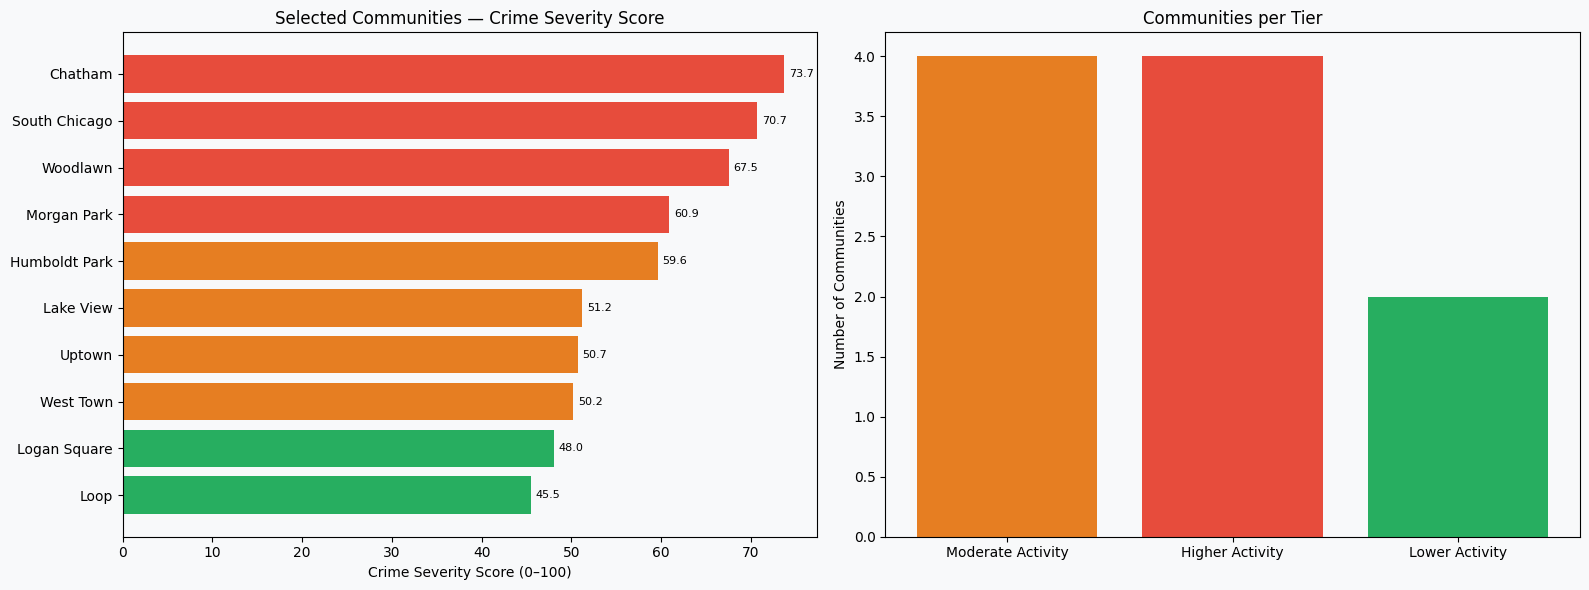

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tier_colors = {'Higher Activity': '#e74c3c', 'Moderate Activity': '#e67e22', 'Lower Activity': '#27ae60'}

# -- Left: score bar chart
ax = axes[0]
plot = selected_final.sort_values('crime_severity_score')
ax.barh(
    plot['community_name'],
    plot['crime_severity_score'],
    color=plot['crime_tier'].map(tier_colors)
)
ax.set_xlabel('Crime Severity Score (0–100)')
ax.set_title('Selected Communities — Crime Severity Score')
ax.set_facecolor('#f8f9fa')

for i, (_, row) in enumerate(plot.iterrows()):
    ax.text(row['crime_severity_score'] + 0.5, i, f"{row['crime_severity_score']:.1f}",
            va='center', fontsize=8)

# -- Right: tier breakdown
ax2 = axes[1]
tier_counts = selected_final['crime_tier'].value_counts()
ax2.bar(tier_counts.index, tier_counts.values,
        color=[tier_colors.get(t, 'gray') for t in tier_counts.index])
ax2.set_ylabel('Number of Communities')
ax2.set_title('Communities per Tier')
ax2.set_facecolor('#f8f9fa')

for ax in axes:
    ax.figure.patch.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

## 10. Export Merge-Ready CSV

In [11]:
output_cols = [
    'Community Area', 'community_name', 'source_311_name',
    'total_crimes', 'violent_crimes', 'domestic_crimes', 'arrests',
    'violent_ratio', 'domestic_rate', 'arrest_rate',
    'peak_hour',
    'top_crime_1', 'top_crime_2', 'top_crime_3',
    'crime_severity_score', 'crime_tier'
]

export = selected_final[output_cols].copy()
export.columns = [
    'community_area_code', 'community_name', 'join_key_311',
    'total_crimes', 'violent_crimes', 'domestic_crimes', 'arrests',
    'violent_ratio', 'domestic_rate', 'arrest_rate',
    'peak_hour',
    'top_crime_1', 'top_crime_2', 'top_crime_3',
    'crime_severity_score', 'crime_tier'
]

export.to_csv('../data/crime_severity_by_community.csv', index=False)

print('Saved: data/crime_severity_by_community.csv')
print(f'Shape: {export.shape}')
print()
print('HOW TO MERGE WITH OTHER DATASETS:')
print('  311 data  → join on: 311["NEIGHBORHOOD"] == crime["join_key_311"]')
print('  Reddit    → join on: reddit["neighborhood"] == crime["community_name"] (after NLP extraction)')
print()
print(export[['community_name','join_key_311','crime_severity_score','crime_tier']]
      .sort_values('crime_severity_score', ascending=False).to_string(index=False))

Saved: data/crime_severity_by_community.csv
Shape: (10, 16)

HOW TO MERGE WITH OTHER DATASETS:
  311 data  → join on: 311["NEIGHBORHOOD"] == crime["join_key_311"]
  Reddit    → join on: reddit["neighborhood"] == crime["community_name"] (after NLP extraction)

community_name  join_key_311  crime_severity_score        crime_tier
       Chatham       Chatham                73.700   Higher Activity
 South Chicago South Chicago                70.700   Higher Activity
      Woodlawn      Woodlawn                67.500   Higher Activity
   Morgan Park   Morgan Park                60.900   Higher Activity
 Humboldt Park Humboldt Park                59.600 Moderate Activity
     Lake View      Lakeview                51.200 Moderate Activity
        Uptown        Uptown                50.700 Moderate Activity
     West Town   Wicker Park                50.200 Moderate Activity
  Logan Square  Logan Square                48.000    Lower Activity
          Loop          Loop                45.500

## 11. Quick Sanity Check — Key Metrics per Community

In [12]:
display_cols = ['community_name', 'total_crimes', 'violent_ratio',
                'domestic_rate', 'arrest_rate', 'peak_hour',
                'top_crime_1', 'crime_severity_score', 'crime_tier']

export_display = export.copy()
export_display.columns = output_cols  # restore readable names for display

export.sort_values('crime_severity_score', ascending=False).style \
    .background_gradient(subset=['crime_severity_score'], cmap='RdYlGn_r') \
    .format({'violent_ratio': '{:.1%}', 'domestic_rate': '{:.1%}',
             'arrest_rate': '{:.1%}', 'crime_severity_score': '{:.1f}'})

,community_area_code,community_name,join_key_311,total_crimes,violent_crimes,domestic_crimes,arrests,violent_ratio,domestic_rate,arrest_rate,peak_hour,top_crime_1,top_crime_2,top_crime_3,crime_severity_score,crime_tier
7,44,Chatham,Chatham,5697,2135,1470,851,37.5%,25.8%,14.9%,0,THEFT,BATTERY,CRIMINAL DAMAGE,73.7,Higher Activity
8,46,South Chicago,South Chicago,3823,1494,1061,551,39.1%,27.8%,14.4%,0,BATTERY,CRIMINAL DAMAGE,THEFT,70.7,Higher Activity
6,42,Woodlawn,Woodlawn,3802,1455,932,555,38.3%,24.5%,14.6%,0,BATTERY,THEFT,CRIMINAL DAMAGE,67.5,Higher Activity
9,75,Morgan Park,Morgan Park,1711,593,448,198,34.7%,26.2%,11.6%,12,THEFT,BATTERY,CRIMINAL DAMAGE,60.9,Higher Activity
3,23,Humboldt Park,Humboldt Park,4144,1515,864,1099,36.6%,20.8%,26.5%,0,BATTERY,NARCOTICS,THEFT,59.6,Moderate Activity
1,6,Lake View,Lakeview,6200,1423,312,585,23.0%,5.0%,9.4%,0,THEFT,BATTERY,DECEPTIVE PRACTICE,51.2,Moderate Activity
0,3,Uptown,Uptown,771,262,116,60,34.0%,15.0%,7.8%,0,THEFT,BATTERY,CRIMINAL DAMAGE,50.7,Moderate Activity
4,24,West Town,Wicker Park,4565,1108,454,492,24.3%,9.9%,10.8%,15,THEFT,BATTERY,MOTOR VEHICLE THEFT,50.2,Moderate Activity
2,22,Logan Square,Logan Square,4426,1060,509,763,23.9%,11.5%,17.2%,0,THEFT,BATTERY,CRIMINAL DAMAGE,48.0,Lower Activity
5,32,Loop,Loop,5792,1491,225,1325,25.7%,3.9%,22.9%,16,THEFT,BATTERY,DECEPTIVE PRACTICE,45.5,Lower Activity


In [ ]:

# ── helpers ───────────────────────────────────────────────────────────────────
DAY_MAP   = {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',
             4:'Friday',5:'Saturday',6:'Sunday'}
MONTH_MAP = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

def peak_val(s):   return s.value_counts().idxmax()
def top_n(s, n=3): return ' | '.join(s.value_counts().head(n).index.tolist())
def pct(s):        return round(s.mean() * 100, 1)

# ── derived columns ───────────────────────────────────────────────────────────
df['day_of_week'] = df['Date'].dt.dayofweek
df['is_night']    = df['hour'].apply(lambda h: h >= 18 or h < 6)  # 6pm–6am
df['peak_month_n']= df['month']

# ── aggregate across ALL community areas (no filtering) ───────────────────────
community_profile = df.groupby('community_name').agg(
    total_incidents  = ('Primary Type',          'count'),
    top_crime_types  = ('Primary Type',          lambda x: top_n(x, 3)),
    violent_pct      = ('is_violent',            pct),
    domestic_pct     = ('is_domestic',           pct),
    arrest_rate_pct  = ('is_arrested',           pct),
    peak_hour        = ('hour',                  peak_val),
    peak_day         = ('day_of_week',           peak_val),
    night_crime_pct  = ('is_night',              pct),
    top_location     = ('Location Description',  peak_val),
    peak_month       = ('peak_month_n',          peak_val),
).reset_index()

# ── readable labels ───────────────────────────────────────────────────────────
community_profile['peak_day']         = community_profile['peak_day'].map(DAY_MAP)
community_profile['peak_month']       = community_profile['peak_month'].map(MONTH_MAP)
community_profile['peak_hour_label']  = community_profile['peak_hour'].apply(
    lambda h: f"{h%12 or 12}{'am' if h<12 else 'pm'}–{(h+1)%12 or 12}{'am' if (h+1)<12 else 'pm'}"
)

community_profile = community_profile.sort_values('total_incidents', ascending=False).reset_index(drop=True)

print(f'Communities: {len(community_profile)}')
print()
community_profile[[
    'community_name', 'total_incidents', 'top_crime_types',
    'violent_pct', 'domestic_pct', 'arrest_rate_pct',
    'peak_hour_label', 'peak_day', 'night_crime_pct',
    'top_location', 'peak_month'
]]


In [ ]:

# ── helpers ──────────────────────────────────────────────────────────────────
DAY_MAP = {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',
           4:'Friday',5:'Saturday',6:'Sunday'}

def peak_val(series):
    return series.value_counts().idxmax()

def top_n(series, n=3):
    return ' | '.join(series.value_counts().head(n).index.tolist())

def pct(series):
    return round(series.mean() * 100, 1)

# ── derived columns (re-use df already loaded above) ─────────────────────────
df['day_of_week']  = df['Date'].dt.dayofweek
df['is_night']     = df['hour'].apply(lambda h: h >= 18 or h < 6)   # 6pm – 6am
df['peak_month_n'] = df['month']                                      # numeric month

MONTH_MAP = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

# ── aggregate ─────────────────────────────────────────────────────────────────
profile = df.groupby('community_name').agg(
    total_incidents   = ('Primary Type',      'count'),
    top_crime_types   = ('Primary Type',      lambda x: top_n(x, 3)),
    violent_pct       = ('is_violent',        pct),
    domestic_pct      = ('is_domestic',       pct),
    arrest_rate_pct   = ('is_arrested',       pct),
    peak_hour         = ('hour',              peak_val),
    peak_day          = ('day_of_week',       peak_val),
    night_crime_pct   = ('is_night',          pct),
    top_location      = ('Location Description', peak_val),
    peak_month        = ('peak_month_n',      peak_val),
).reset_index()

# ── readable labels ───────────────────────────────────────────────────────────
profile['peak_day']   = profile['peak_day'].map(DAY_MAP)
profile['peak_month'] = profile['peak_month'].map(MONTH_MAP)
profile['peak_hour_label'] = profile['peak_hour'].apply(
    lambda h: f"{h % 12 or 12}{'am' if h < 12 else 'pm'}–{(h+1) % 12 or 12}{'am' if (h+1) < 12 else 'pm'}"
)

# ── filter to our 10 selected communities ────────────────────────────────────
selected_communities = [
    'Chatham', 'South Chicago', 'Woodlawn', 'Morgan Park',
    'Humboldt Park', 'Lake View', 'Uptown', 'West Town',
    'Logan Square', 'Loop'
]

community_profile = profile[profile['community_name'].isin(selected_communities)].copy()
community_profile = community_profile.sort_values('total_incidents', ascending=False).reset_index(drop=True)

display_cols = [
    'community_name', 'total_incidents', 'top_crime_types',
    'violent_pct', 'domestic_pct', 'arrest_rate_pct',
    'peak_hour_label', 'peak_day', 'night_crime_pct',
    'top_location', 'peak_month'
]

print(community_profile[display_cols].to_string(index=False))


## 12. Violent Crime Percentage Across All Community Areas

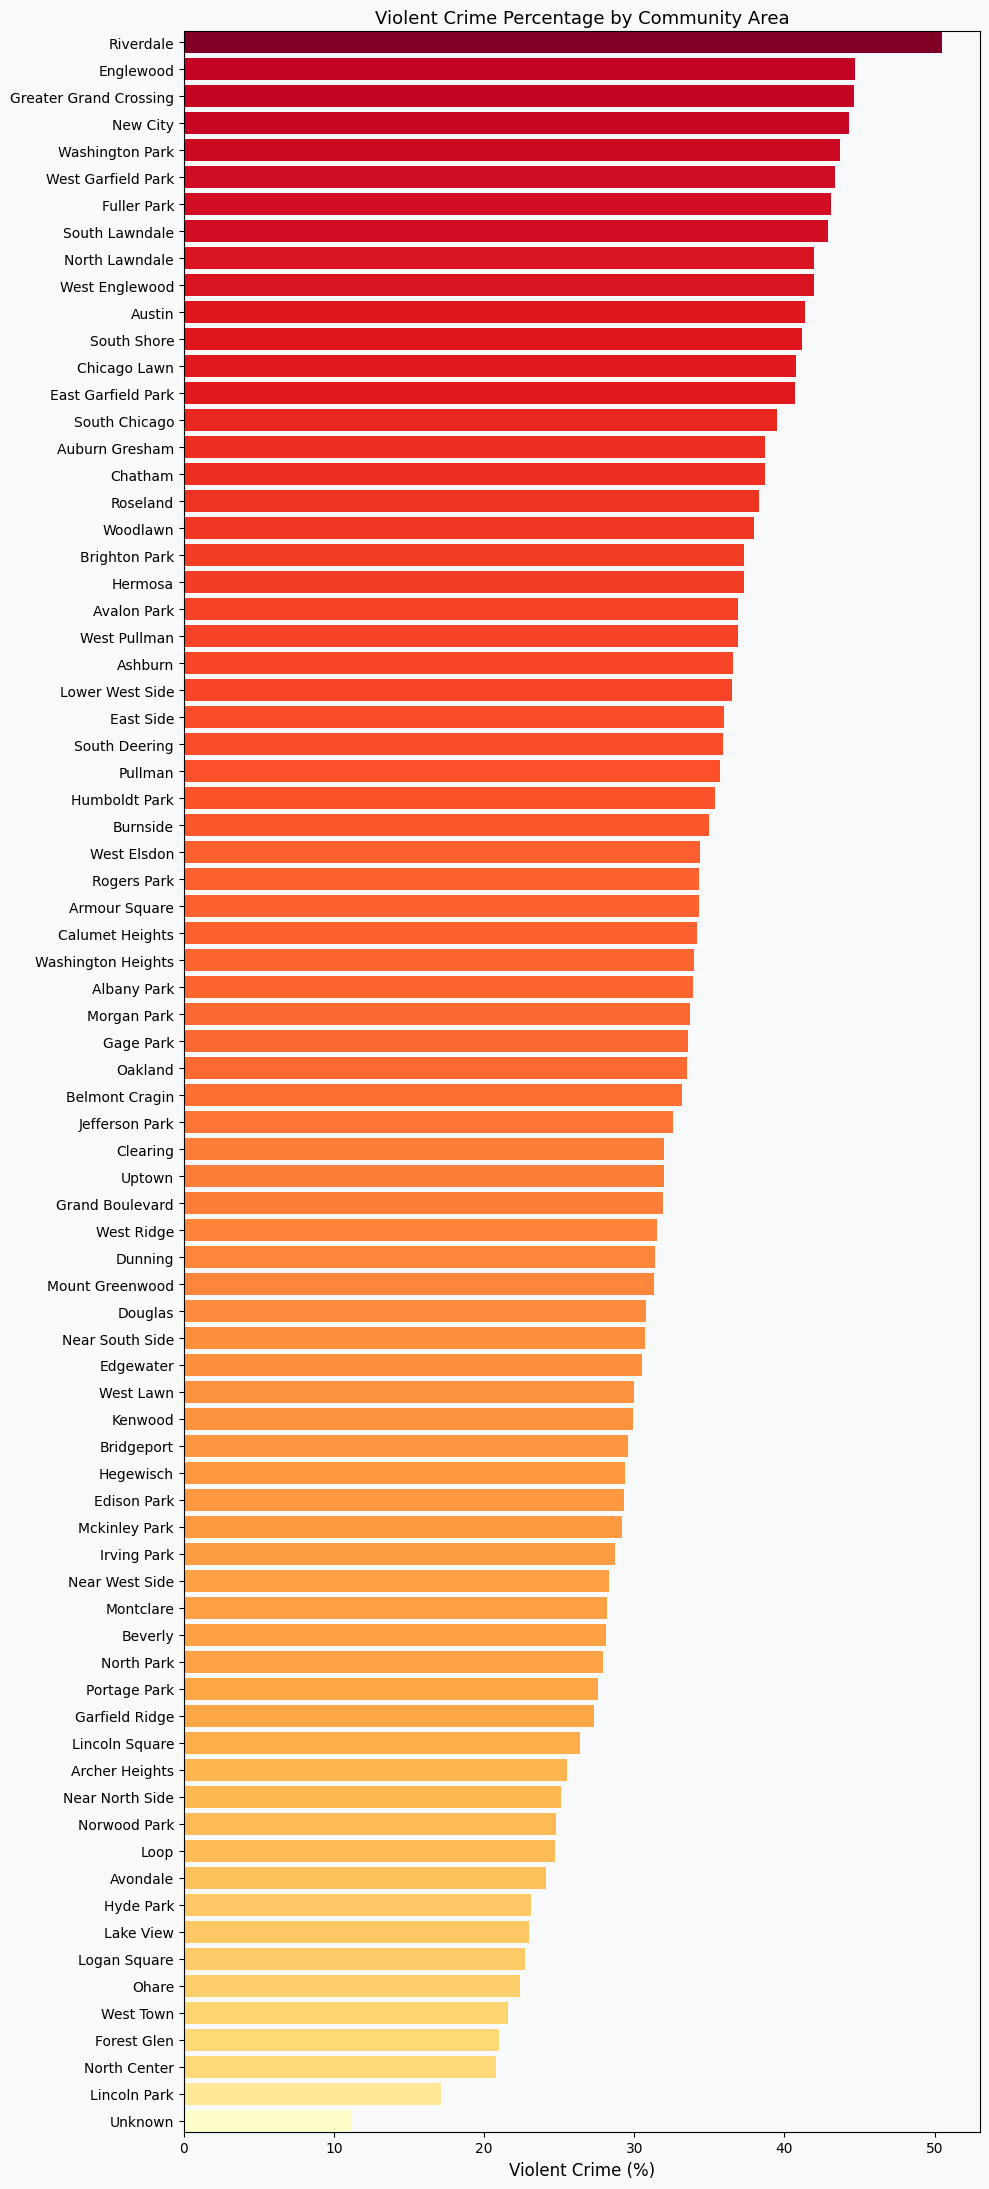

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

profile = pd.read_csv('../chatbot/data/community_crime_profile.csv')
profile = profile.sort_values('violent_pct', ascending=True).reset_index(drop=True)

norm = plt.Normalize(profile['violent_pct'].min(), profile['violent_pct'].max())
colors = cm.YlOrRd(norm(profile['violent_pct']))

fig, ax = plt.subplots(figsize=(10, 22))
ax.barh(profile['neighborhood'], profile['violent_pct'], color=colors)

ax.set_xlabel('Violent Crime (%)', fontsize=12)
ax.set_title('Violent Crime Percentage by Community Area', fontsize=13)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')
ax.margins(y=0)

plt.tight_layout()
plt.show()